# Class 6 - End-to-End Lab

Yelp Restaurants Module 3 lab notebook. This notebook is organized for GitHub review and uses the final clean dataset produced by `scripts/run_pipeline.py`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from yelp_lab.config import FINAL_SCHEMA

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "yelp_restaurants_clean.parquet"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "classes"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DISPLAY_DIR = PROJECT_ROOT / ".cache" / "notebook_figures"
NOTEBOOK_DISPLAY_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
_display_counter = 0

def show_and_close():
    global _display_counter
    for number in plt.get_fignums():
        _display_counter += 1
        fig = plt.figure(number)
        display_path = NOTEBOOK_DISPLAY_DIR / f"figure_{_display_counter:03d}.png"
        fig.savefig(display_path, dpi=160, bbox_inches="tight")
        display(Image(filename=str(display_path)))
    plt.close("all")

plt.show = show_and_close

print(df.shape)
df.head()

(5852, 22)


,business_id,state,city,latitude,longitude,dist_from_center,n_categories,price_range_num,has_wifi,has_parking,...,alcohol_num,noise_level_num,hours_open_per_week,n_days_open,review_count,log_review_count,review_velocity,mean_review_length,mean_review_sentiment_score,stars
0,MTSW4McQd7CbVtyjqoe9mw,PA,Philadelphia,39.955505,-75.155564,0.882586,5,1,1,1,...,0,0,94.0,7,80,4.394449,6.374473,558.919540,2.160920,4.0
1,MUTTqe8uqyMdBl186RmNeA,PA,Philadelphia,39.953949,-75.143226,1.879011,3,2,1,1,...,2,2,53.0,6,245,5.505332,60.471854,647.640000,3.772000,4.0
2,ROeacJQwBeh05Rqg7F6TCg,PA,Philadelphia,39.943223,-75.162568,1.066541,2,1,0,1,...,0,1,54.0,6,205,5.327876,25.700947,432.432692,2.533654,4.5
3,QdN72BWoyFypdGJhhI5r7g,PA,Philadelphia,39.939825,-75.157447,1.566801,5,2,1,1,...,2,2,78.0,7,65,4.189655,20.932101,514.275362,2.826087,4.0
4,Mjboz24M9NlBeiOJKLEd_Q,PA,Philadelphia,40.022466,-75.218314,8.990560,4,1,0,0,...,0,2,41.0,6,41,3.737670,7.779351,470.146341,1.000000,3.0


## Goal

Validate the final 22-column dataset and package the findings for Priya.

Original PDF tasks:
- Produce `yelp_restaurants_clean.parquet`.
- Validate the exact 22-column schema.
- Reuse the most important charts.
- Write `findings.md`.

In [2]:
assert list(df.columns) == FINAL_SCHEMA
assert df["business_id"].duplicated().sum() == 0
assert df["stars"].between(1, 5).all()
print("Final schema validated.")
print("Rows:", len(df))
print("Mean stars:", round(df["stars"].mean(), 3))
df.dtypes

Final schema validated.
Rows: 5852
Mean stars: 3.556


business_id                     string
state                           string
city                            string
latitude                       float64
longitude                      float64
dist_from_center               float64
n_categories                     int64
price_range_num                  int64
has_wifi                         int64
has_parking                      int64
accepts_credit_cards             int64
outdoor_seating                  int64
alcohol_num                      int64
noise_level_num                  int64
hours_open_per_week            float64
n_days_open                      int64
review_count                     int64
log_review_count               float64
review_velocity                float64
mean_review_length             float64
mean_review_sentiment_score    float64
stars                          float64
dtype: object

## Required Final Schema

In [3]:
pd.DataFrame({"column_number": range(1, len(FINAL_SCHEMA) + 1), "column_name": FINAL_SCHEMA})

,column_number,column_name
0,1,business_id
1,2,state
2,3,city
3,4,latitude
4,5,longitude
5,6,dist_from_center
6,7,n_categories
7,8,price_range_num
8,9,has_wifi
9,10,has_parking


## Exploratory Chart 1 - Target Distribution

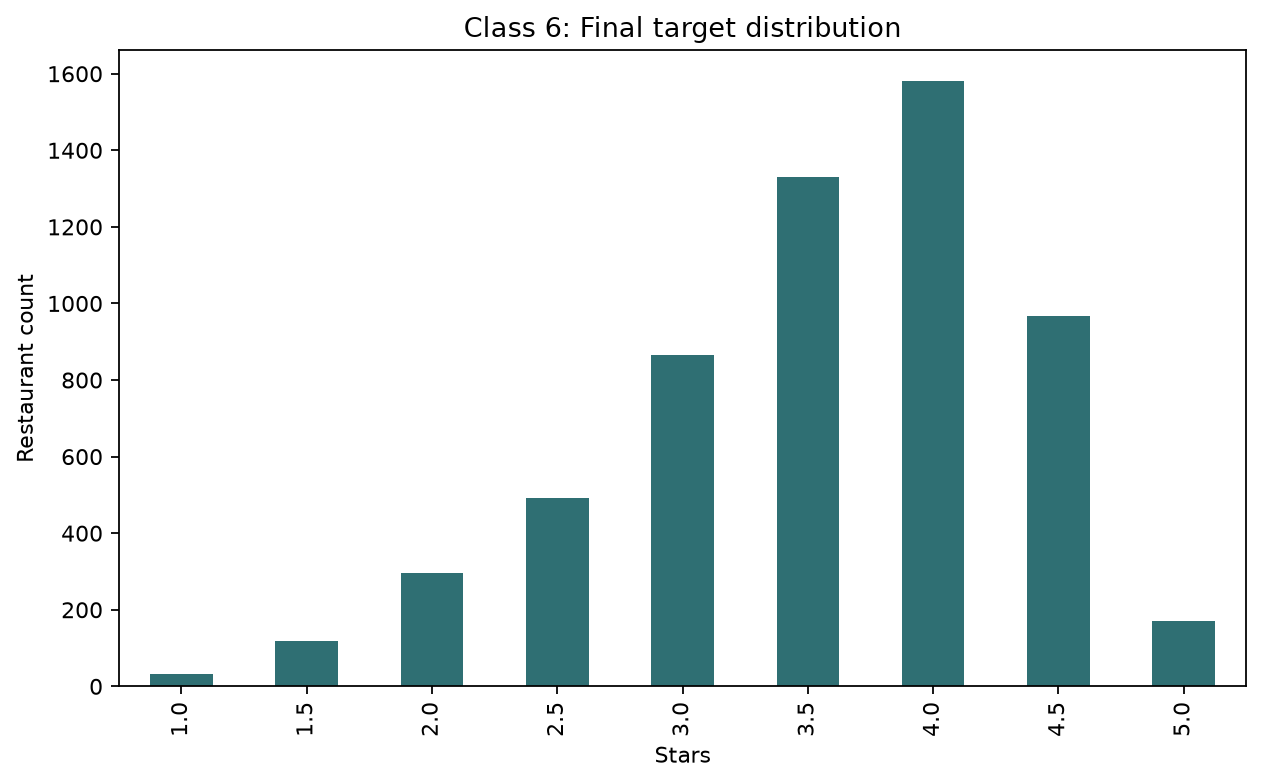

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
df["stars"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#2f6f73")
ax.set_title("Class 6: Final target distribution")
ax.set_xlabel("Stars")
ax.set_ylabel("Restaurant count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class6_exploratory_target_distribution.png", dpi=160)
plt.show()

## Exploratory Chart 2 - Final Feature Correlations

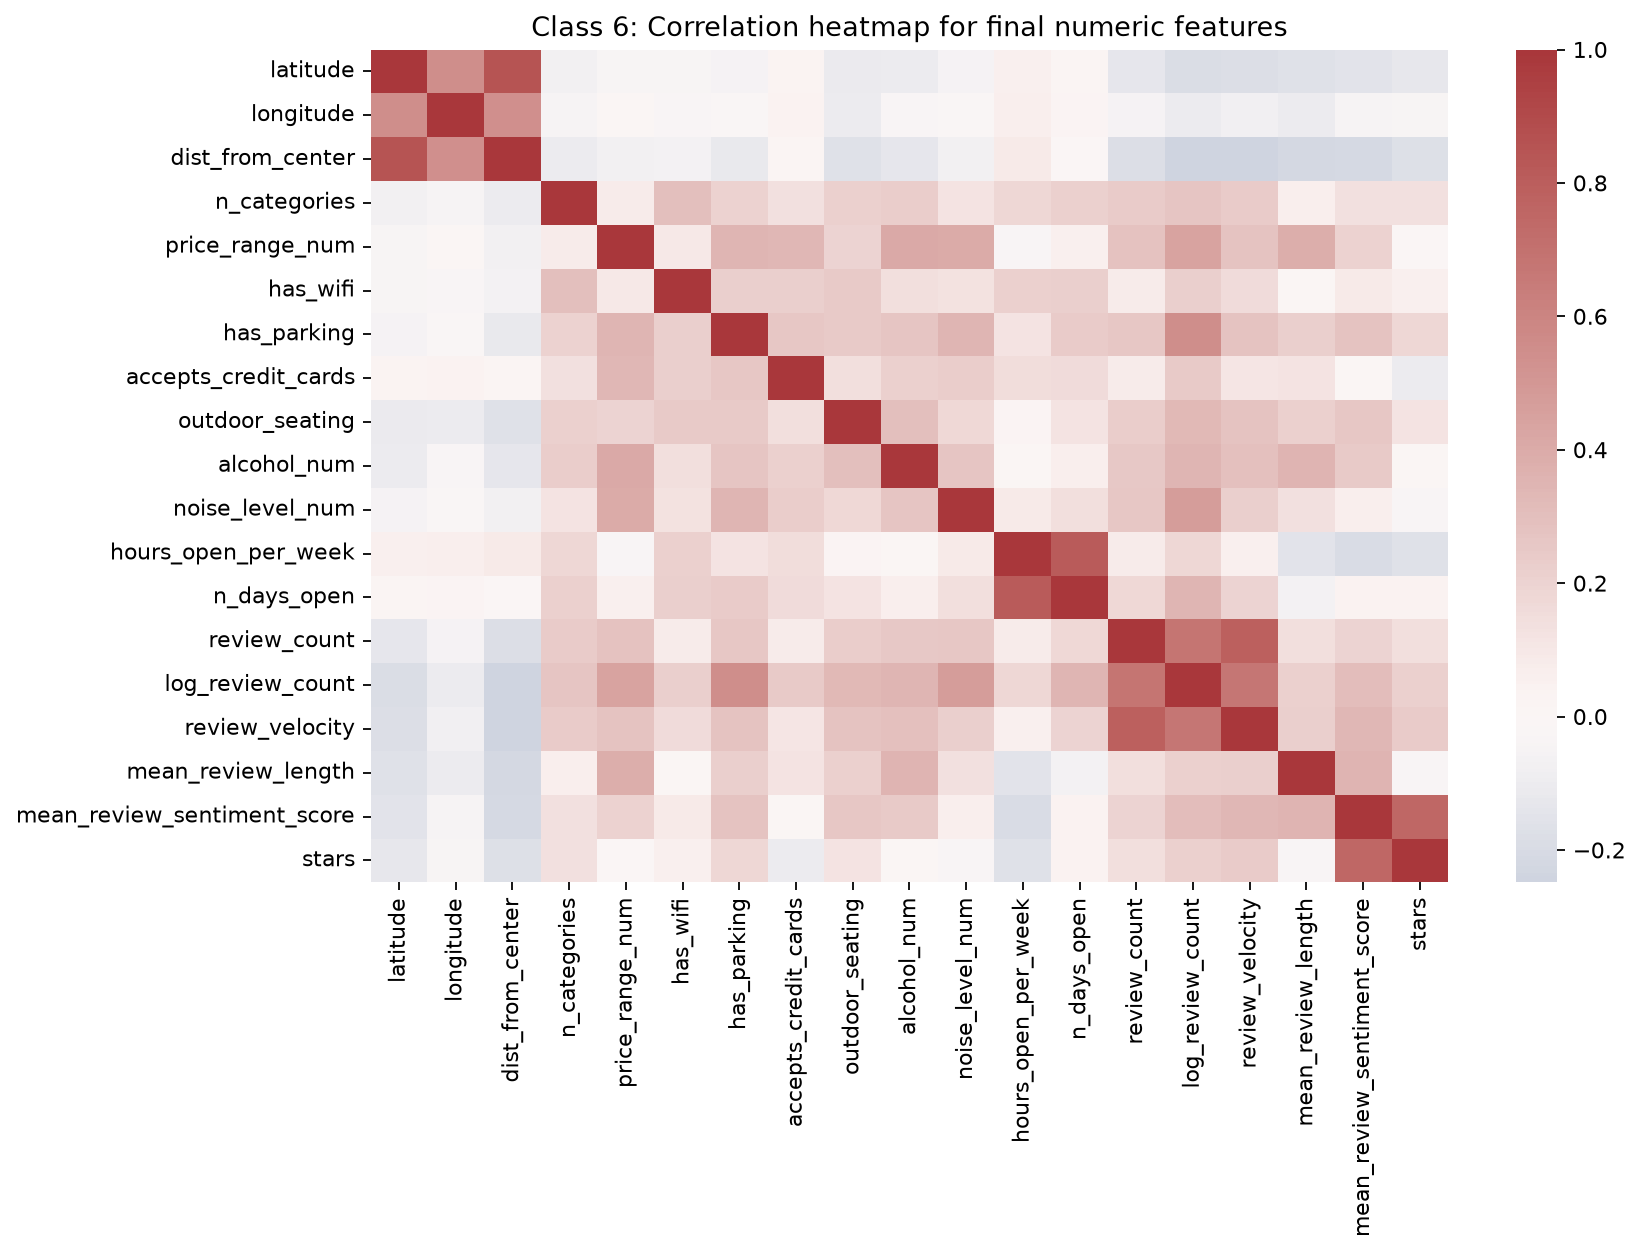

In [5]:
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df.select_dtypes(include=["number"]).corr(), cmap="vlag", center=0, ax=ax)
ax.set_title("Class 6: Correlation heatmap for final numeric features")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class6_exploratory_final_correlations.png", dpi=160)
plt.show()

## Exploratory Chart 3 - Launch vs Review Feature Groups

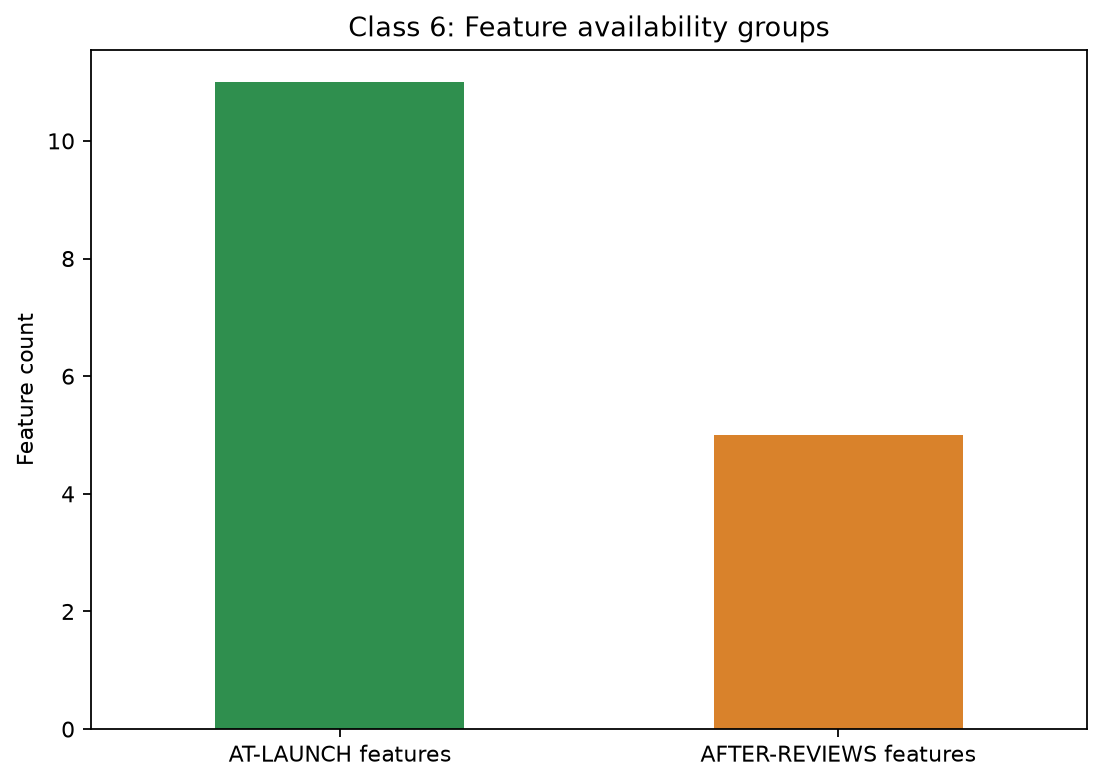

In [6]:
launch_features = [
    "dist_from_center", "n_categories", "price_range_num", "has_wifi",
    "has_parking", "accepts_credit_cards", "outdoor_seating", "alcohol_num",
    "noise_level_num", "hours_open_per_week", "n_days_open"
]
review_features = ["review_count", "log_review_count", "review_velocity", "mean_review_length", "mean_review_sentiment_score"]
summary = pd.Series({
    "AT-LAUNCH features": len(launch_features),
    "AFTER-REVIEWS features": len(review_features),
})
fig, ax = plt.subplots(figsize=(7, 5))
summary.plot(kind="bar", ax=ax, color=["#2f8f4e", "#d9822b"])
ax.set_title("Class 6: Feature availability groups")
ax.set_ylabel("Feature count")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class6_exploratory_feature_groups.png", dpi=160)
plt.show()

## Explanatory Chart for Priya - Final Summary

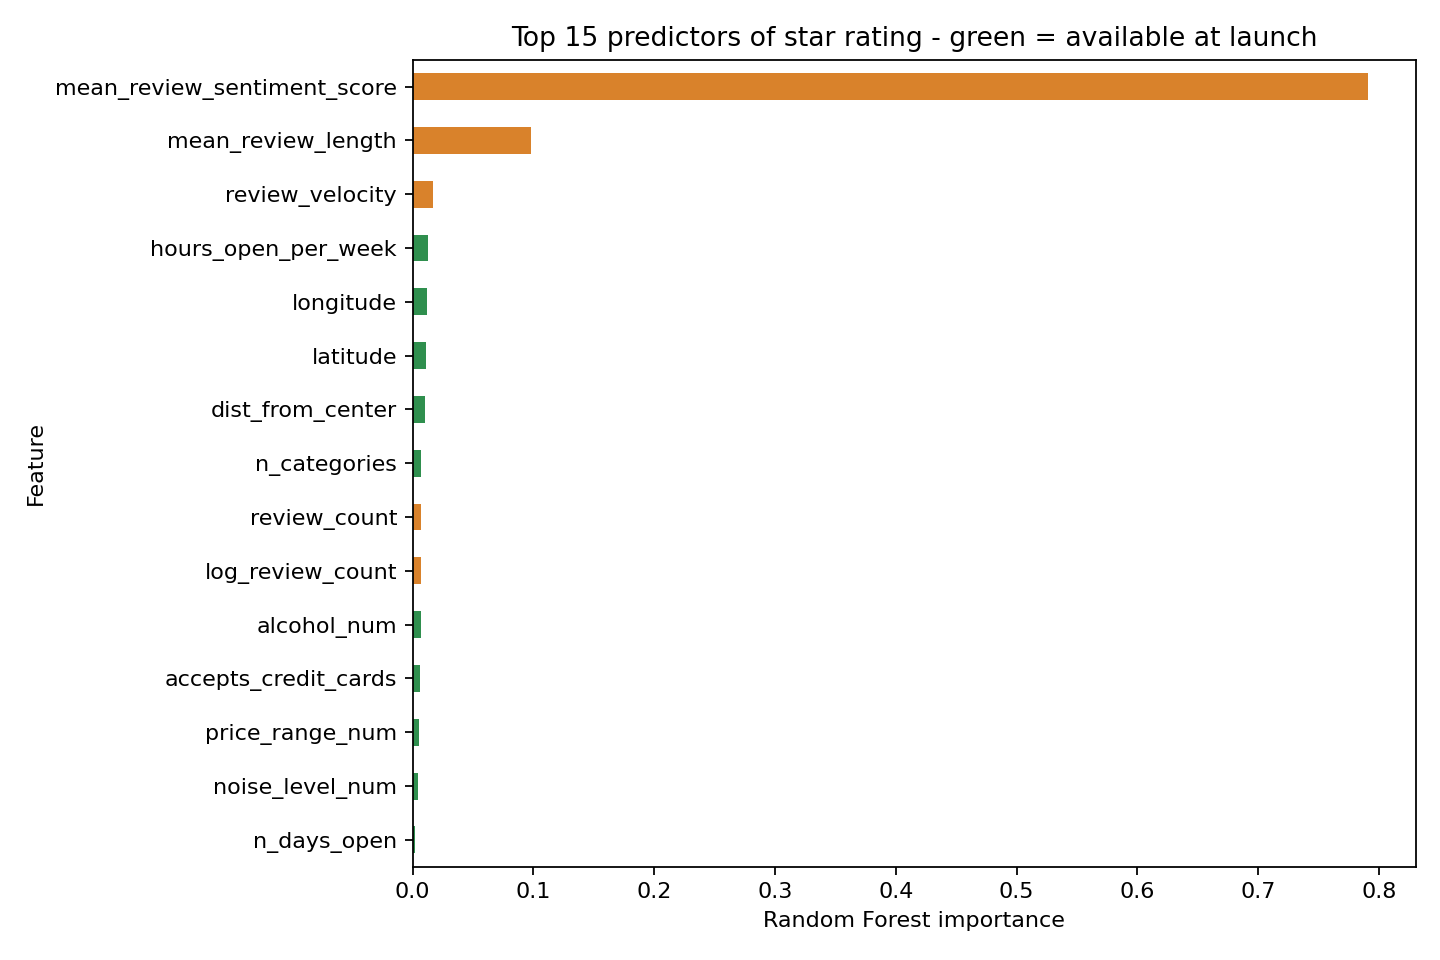

Takeaway: Review-based features are strongest, but the project clearly separates launch-time and after-review signals for future cold-start modeling.


In [7]:
importance_path = PROJECT_ROOT / "reports" / "figures" / "top_feature_importance.png"
if importance_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(importance_path)))
print("Takeaway: Review-based features are strongest, but the project clearly separates launch-time and after-review signals for future cold-start modeling.")

## Final Submission Checklist

- `data/processed/yelp_restaurants_clean.parquet` exists.
- `reports/findings.md` exists.
- Class notebooks include exploratory and explanatory charts.
- Raw Yelp files are intentionally excluded from GitHub.